# View Mid-Z Time Samples

In [15]:
from pathlib import Path

import pandas as pd

from zebrafish_notebook_utils import (
    build_compound_image_condition_map,
    build_compound_image_run_map,
    configure_full_dataframe_display,
    load_image_condition_tensor,
    plot_midz_time_slices_from_tensor,
)

In [16]:
configure_full_dataframe_display()

compound_image_map_df = build_compound_image_run_map()
condition_df = build_compound_image_condition_map(compound_image_map_df)
condition_df.shape

(2376, 20)

In [17]:
# User inputs
xy_size = 128
selected_compound = "Amphetamine"
selector_column = "concentration_band"  # use "concentration_band" or "concentration_label"
selected_concentration = "high"
only_active = True
tensor_size = (10, 1, xy_size, xy_size)  # (T, Z, Y, X); use None to keep a source dimension unchanged
n_columns = 5
selected_condition_index = 0

In [18]:
condition_tensor = load_image_condition_tensor(
    condition_df=condition_df,
    selected_compound=selected_compound,
    selector_column=selector_column,
    selected_concentration=selected_concentration,
    only_active=only_active,
    selected_condition_index=selected_condition_index,
    output_size=tensor_size,
)
condition_tensor.shape

torch.Size([10, 1, 128, 128])

In [19]:
selected_condition_label = (
    f"{selected_compound} | {selector_column}={selected_concentration} | "
    f"condition_index={selected_condition_index}"
)
selected_condition_label

'Amphetamine | concentration_band=high | condition_index=0'

In [20]:
condition_tensor.shape

torch.Size([10, 1, 128, 128])

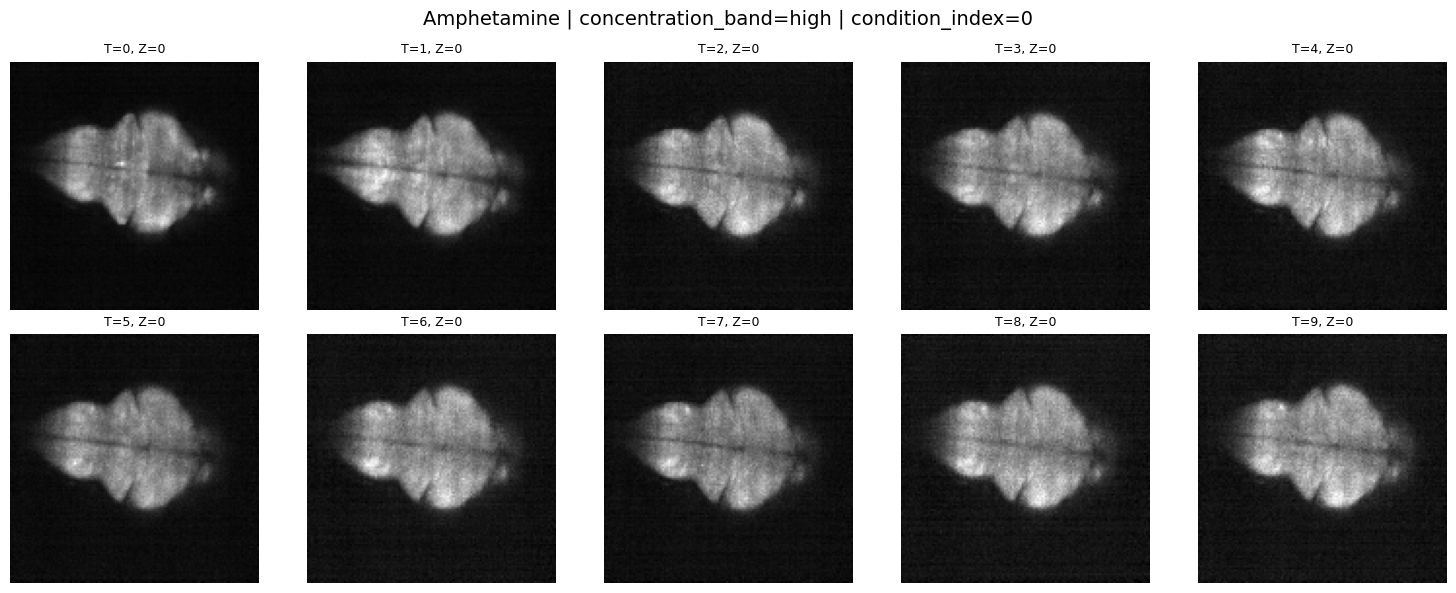

In [21]:
plot_midz_time_slices_from_tensor(
    condition_tensor,
    n_columns=n_columns,
    title=selected_condition_label,
);